In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df=pd.read_csv('steam_games_preprocessed.csv')
df.head()

,release_year,price,recommendations,main_genre,developer_Archor Wright,developer_Blessing Company,developer_Boogygames Studios,developer_Bully Revenge Studios,developer_Creobit,developer_Cute Hannah's Games,...,Steam Turn Notifications,Steam Workshop,Stereo Sound,Subtitle Options,Surround Sound,Touch Only Option,Tracked Controller Support,VR Only,VR Support,VR Supported
0,2024,3.99,0,Action,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,2025,7.99,0,Casual,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,2025,12.99,0,Adventure,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,2023,24.99,0,Action,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,2021,3.99,0,Action,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [31]:
num_bool_cols = df.select_dtypes(include=['number', 'bool']).columns

print(len(num_bool_cols))
print(num_bool_cols.tolist())

78
['release_year', 'price', 'recommendations', 'developer_Archor Wright', 'developer_Blessing Company', 'developer_Boogygames Studios', 'developer_Bully Revenge Studios', 'developer_Creobit', "developer_Cute Hannah's Games", 'developer_Cyber Keks', 'developer_CyberStep, Inc.;Rideon Works Co. Ltd,', 'developer_Do Games Limited', 'developer_EpiXR Games UG', 'developer_EroticGamesClub', 'developer_Follow the fun', 'developer_Gamesforgames', 'developer_Hede', 'developer_Kairosoft Co.,Ltd', 'developer_King Kong', 'developer_LTZinc', 'developer_Laush Dmitriy Sergeevich', 'developer_NaipSoft', 'developer_Other', 'developer_SAT-BOX', 'Adjustable Difficulty', 'Adjustable Text Size', 'Camera Comfort', 'Captions available', 'Chat Speech-to-text', 'Chat Text-to-speech', 'Co-op', 'Color Alternatives', 'Commentary available', 'Cross-Platform Multiplayer', 'Custom Volume Controls', 'Family Sharing', 'Full controller support', 'HDR available', 'In-App Purchases', 'Includes Source SDK', 'Includes leve

In [32]:
len(df.columns)

79

In [33]:
df["main_genre"].nunique()

11

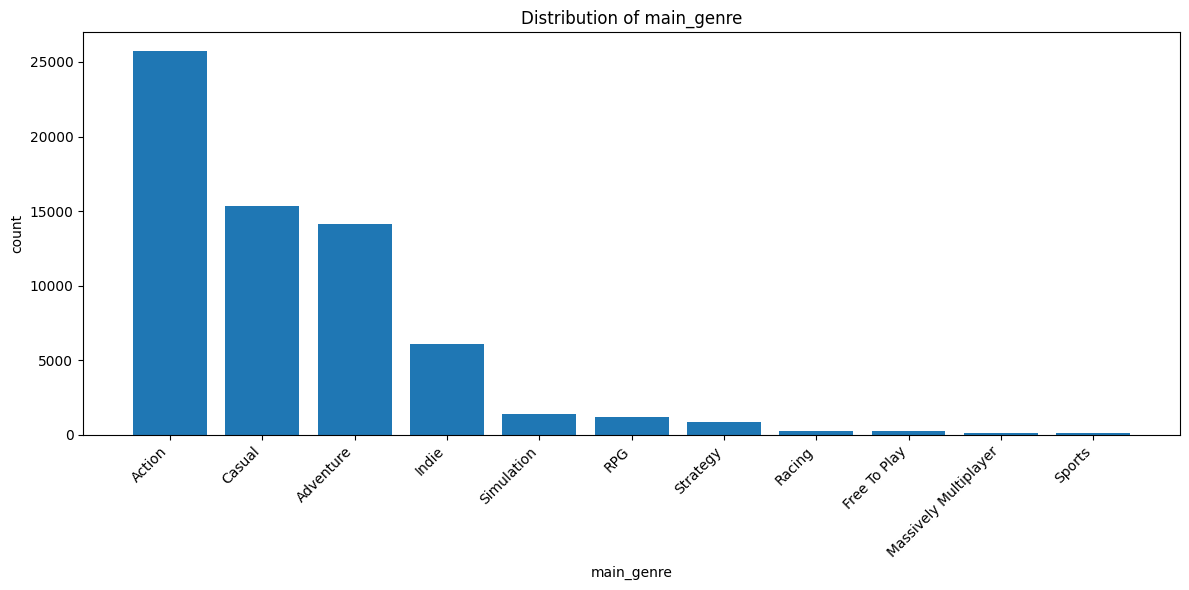

In [34]:
genre_counts = df["main_genre"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(genre_counts.index, genre_counts.values)

plt.xlabel("main_genre")
plt.ylabel("count")
plt.title("Distribution of main_genre")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 정답 컬럼
target_col = "main_genre"

# X, y 분리
X = df.drop(columns=[target_col])
y = df[target_col]

# y 문자열 라벨을 정수로 변환
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("클래스 개수:", len(label_encoder.classes_))
print("클래스 목록:", label_encoder.classes_)

클래스 개수: 11
클래스 목록: ['Action' 'Adventure' 'Casual' 'Free To Play' 'Indie'
 'Massively Multiplayer' 'RPG' 'Racing' 'Simulation' 'Sports' 'Strategy']


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [37]:
numerical_cols = ['release_year', 'price', 'recommendations']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train's numerical columns and transform both X_train and X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

print("X_train_scaled head:")
display(X_train_scaled.head())
print("X_test_scaled head:")
display(X_test_scaled.head())

X_train_scaled head:


,release_year,price,recommendations,developer_Archor Wright,developer_Blessing Company,developer_Boogygames Studios,developer_Bully Revenge Studios,developer_Creobit,developer_Cute Hannah's Games,developer_Cyber Keks,...,Steam Turn Notifications,Steam Workshop,Stereo Sound,Subtitle Options,Surround Sound,Touch Only Option,Tracked Controller Support,VR Only,VR Support,VR Supported
19616,1.117244,0.042598,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1120,1.117244,-0.298237,-0.050317,False,False,False,False,False,False,False,...,0,0,1,0,0,0,0,0,0,0
38603,0.395842,-0.411281,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
60219,1.117244,-0.355043,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
39623,0.395842,-0.355043,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


X_test_scaled head:


,release_year,price,recommendations,developer_Archor Wright,developer_Blessing Company,developer_Boogygames Studios,developer_Bully Revenge Studios,developer_Creobit,developer_Cute Hannah's Games,developer_Cyber Keks,...,Steam Turn Notifications,Steam Workshop,Stereo Sound,Subtitle Options,Surround Sound,Touch Only Option,Tracked Controller Support,VR Only,VR Support,VR Supported
25876,1.117244,-0.241431,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
884,1.117244,-0.127819,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2560,-1.768365,-0.355043,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
34406,-1.768365,0.724270,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
54673,-1.768365,0.383434,-0.050317,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [38]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split as sklearn_train_test_split

# Define hyperparameters globally for easier modification
batch_size = 128
learning_rate = 0.001
num_epochs = 30

# Split X_train_scaled and y_train into training and validation sets for PyTorch
X_train_pt, X_val_pt, y_train_pt, y_val_pt = sklearn_train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2, # 20% of the original X_train for validation
    random_state=42,
    stratify=y_train
)

# Convert DataFrames/arrays to PyTorch tensors
# Ensure all values are numerical (float32) by casting the entire DataFrame to float first
X_train_tensor = torch.tensor(X_train_pt.astype(float).values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_pt, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_pt.astype(float).values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_pt, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled.astype(float).values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset_pt = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset_pt = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset_pt = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader_pt = DataLoader(train_dataset_pt, batch_size=batch_size, shuffle=True)
val_loader_pt = DataLoader(val_dataset_pt, batch_size=batch_size, shuffle=False)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"Number of batches in train_loader: {len(train_loader_pt)}")
print(f"Number of batches in val_loader: {len(val_loader_pt)}")
print(f"Number of batches in test_loader: {len(test_loader_pt)}")

X_train_tensor shape: torch.Size([41846, 78])
y_train_tensor shape: torch.Size([41846])
Number of batches in train_loader: 327
Number of batches in val_loader: 82
Number of batches in test_loader: 103


In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha # Can be a tensor of weights for each class
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs are logits, targets are class indices
        # Apply softmax to get probabilities
        p = F.softmax(inputs, dim=1)

        # Select the probability of the true class
        # Add a small epsilon to prevent log(0) if p is exactly 0
        p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1) + 1e-8

        # Calculate cross entropy loss
        ce_loss = -torch.log(p_t)

        # Calculate focal loss term
        focal_term = (1 - p_t) ** self.gamma

        # Apply alpha if provided
        if self.alpha is not None:
            if not isinstance(self.alpha, torch.Tensor):
                # Ensure alpha is a tensor and on the correct device
                self.alpha = torch.tensor(self.alpha, dtype=inputs.dtype, device=inputs.device)
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * focal_term * ce_loss
        else:
            loss = focal_term * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else: # 'none'
            return loss

In [40]:
import numpy as np

# Check class distribution of y_train
class_counts = pd.Series(y_train).value_counts().sort_index()

print("y_train main_genre class distribution:")
for idx, count in class_counts.items():
    print(f"Class {idx} (Genre: {label_encoder.inverse_transform([idx])[0]}): {count} samples")

# Calculate class weights for Focal Loss with a normalized inverse frequency approach
# This aims to provide higher weights for minority classes, but within a more controlled range.
if len(class_counts) > 0 and len(np.unique(y_train)) > 1:
    # Calculate inverse frequencies and apply sqrt
    # Adding a small epsilon to avoid division by zero for classes with 0 samples (though unlikely with stratify)
    raw_weights = 1.0 / np.sqrt(class_counts.values + 1e-8)
    # Normalize weights so their sum is proportional to the number of classes, or mean is 1
    class_weights_alpha = raw_weights / np.mean(raw_weights)
    class_weights_tensor = torch.tensor(class_weights_alpha, dtype=torch.float32)

    print("\nCalculated class weights (for CrossEntropyLoss weight) using sqrt(1/count) normalization:")
    for idx, weight in enumerate(class_weights_alpha):
        print(f"Class {idx} (Genre: {label_encoder.inverse_transform([idx])[0]}): {weight:.2f}")
else:
    class_weights_tensor = None
    print("Class weights not calculated due to insufficient data or single class.")

y_train main_genre class distribution:
Class 0 (Genre: Action): 20562 samples
Class 1 (Genre: Adventure): 11289 samples
Class 2 (Genre: Casual): 12276 samples
Class 3 (Genre: Free To Play): 218 samples
Class 4 (Genre: Indie): 4849 samples
Class 5 (Genre: Massively Multiplayer): 98 samples
Class 6 (Genre: RPG): 937 samples
Class 7 (Genre: Racing): 222 samples
Class 8 (Genre: Simulation): 1109 samples
Class 9 (Genre: Sports): 83 samples
Class 10 (Genre: Strategy): 665 samples

Calculated class weights (for CrossEntropyLoss weight) using sqrt(1/count) normalization:
Class 0 (Genre: Action): 0.16
Class 1 (Genre: Adventure): 0.21
Class 2 (Genre: Casual): 0.20
Class 3 (Genre: Free To Play): 1.53
Class 4 (Genre: Indie): 0.32
Class 5 (Genre: Massively Multiplayer): 2.28
Class 6 (Genre: RPG): 0.74
Class 7 (Genre: Racing): 1.52
Class 8 (Genre: Simulation): 0.68
Class 9 (Genre: Sports): 2.48
Class 10 (Genre: Strategy): 0.88


In [41]:
import torch.nn as nn
import torch.nn.functional as F

# Get number of input features (columns in X_train_scaled)
input_size = X_train_scaled.shape[1]

# Get number of output classes (genres)
output_size = len(label_encoder.classes_)

class DNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.3)

        self.fc_out = nn.Linear(64, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout3(x)

        x = self.fc_out(x)
        return x

model_pt = DNN(input_size, output_size)

# Move model to GPU if available before defining criterion with weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_pt.to(device)

# Define loss function (CrossEntropyLoss with sqrt(1/count) class weights) and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device)) # Using CrossEntropyLoss with sqrt(1/count) class weights
optimizer = torch.optim.Adam(model_pt.parameters(), lr=learning_rate)

print(model_pt)

DNN(
  (fc1): Linear(in_features=78, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=64, out_features=11, bias=True)
)


Epoch [1/30], Train Loss: 1.9507, Train Acc: 0.3787, Val Loss: 1.8198, Val Acc: 0.4228
Epoch [2/30], Train Loss: 1.8324, Train Acc: 0.4069, Val Loss: 1.7909, Val Acc: 0.4227
Epoch [3/30], Train Loss: 1.8060, Train Acc: 0.4185, Val Loss: 1.7800, Val Acc: 0.4301
Epoch [4/30], Train Loss: 1.7904, Train Acc: 0.4194, Val Loss: 1.7775, Val Acc: 0.4283
Epoch [5/30], Train Loss: 1.7837, Train Acc: 0.4196, Val Loss: 1.7694, Val Acc: 0.4302
Epoch [6/30], Train Loss: 1.7759, Train Acc: 0.4216, Val Loss: 1.7633, Val Acc: 0.4245
Epoch [7/30], Train Loss: 1.7647, Train Acc: 0.4219, Val Loss: 1.7651, Val Acc: 0.4267
Epoch [8/30], Train Loss: 1.7625, Train Acc: 0.4240, Val Loss: 1.7619, Val Acc: 0.4198
Epoch [9/30], Train Loss: 1.7596, Train Acc: 0.4237, Val Loss: 1.7615, Val Acc: 0.4261
Epoch [10/30], Train Loss: 1.7551, Train Acc: 0.4254, Val Loss: 1.7579, Val Acc: 0.4181
Epoch [11/30], Train Loss: 1.7502, Train Acc: 0.4226, Val Loss: 1.7622, Val Acc: 0.4233
Epoch [12/30], Train Loss: 1.7490, Train 

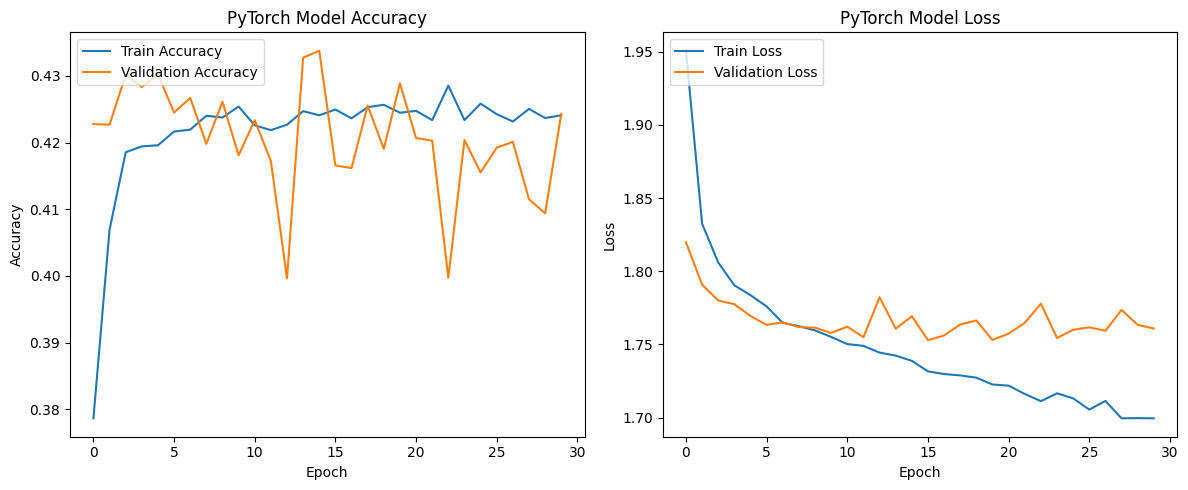

In [42]:
import matplotlib.pyplot as plt

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_pt.to(device)

for epoch in range(num_epochs):
    model_pt.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader_pt:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_pt(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader_pt)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    model_pt.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader_pt:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_pt(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader_pt)
    epoch_val_accuracy = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}')

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('PyTorch Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('PyTorch Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Test Accuracy: 42.79%

Classification Report:
                       precision    recall  f1-score   support

               Action       0.53      0.65      0.58      5140
            Adventure       0.32      0.37      0.34      2822
               Casual       0.42      0.36      0.39      3069
         Free To Play       0.05      0.25      0.08        55
                Indie       0.37      0.03      0.05      1212
Massively Multiplayer       0.15      0.80      0.25        25
                  RPG       0.26      0.09      0.13       234
               Racing       0.09      0.13      0.10        55
           Simulation       0.15      0.05      0.08       278
               Sports       0.02      0.05      0.03        21
             Strategy       0.12      0.10      0.11       166

             accuracy                           0.43     13077
            macro avg       0.23      0.26      0.19     13077
         weighted avg       0.42      0.43      0.41     13077



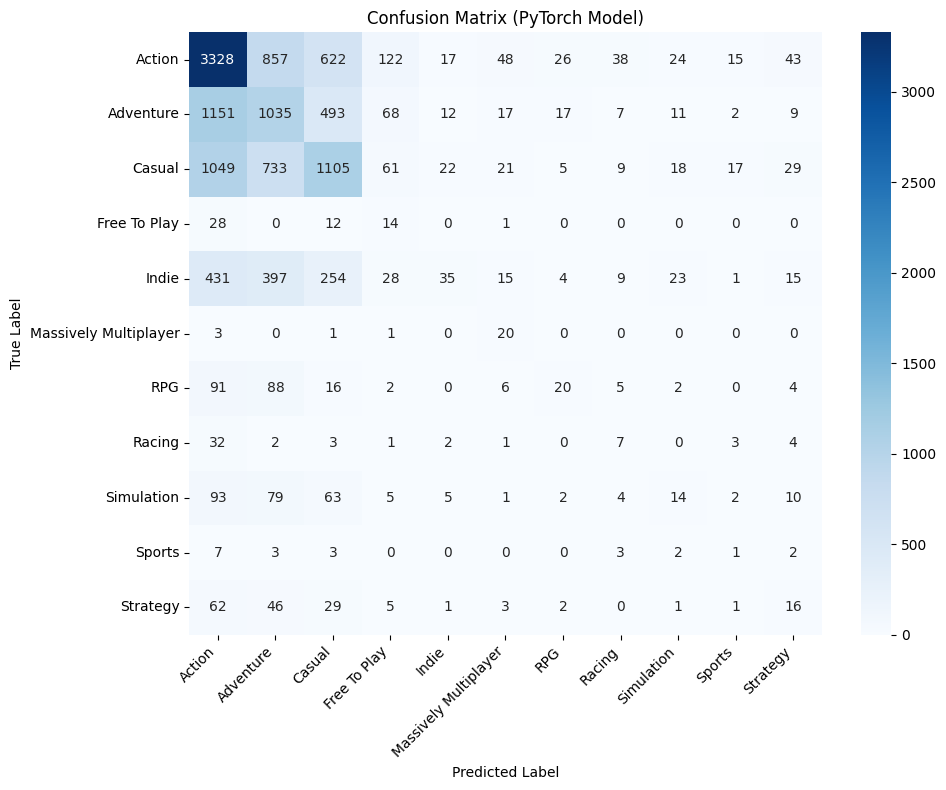

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Evaluate the model on the test set
model_pt.eval() # Set model to evaluation mode
correct_test = 0
total_test = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader_pt:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = correct_test / total_test
print(f"Test Accuracy: {test_accuracy:.2%}") # Formatted as percentage

# Scikit-learn metrics
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=label_encoder.classes_))

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (PyTorch Model)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Addressing Class Imbalance with SMOTE (Synthetic Minority Over-sampling Technique)

The `classification_report` from the previous run clearly shows very low recall and f1-scores for minority classes (e.g., 'Free To Play', 'Massively Multiplayer', 'Sports', 'Racing', 'Simulation', 'RPG', 'Strategy', 'Indie', 'Adventure'). This is a common problem in imbalanced datasets, where the model struggles to learn meaningful patterns for underrepresented classes.

SMOTE is an oversampling technique that generates synthetic samples from the minority class. It works by taking samples from the minority class, and for each sample, finding its k-nearest neighbors. Then, it creates new synthetic samples by randomly selecting one of the k-nearest neighbors and creating a new sample at a random point along the line segment between the original sample and the selected neighbor.

This approach helps to:
- Increase the number of minority class samples, making the dataset more balanced.
- Provide more diverse examples for the minority classes, preventing overfitting to specific minority instances.

We will apply SMOTE to the training data (`X_train_scaled`, `y_train`) to balance the classes before retraining the neural network. Since SMOTE will balance the dataset, we will revert to using `nn.CrossEntropyLoss()` without any explicit class weights initially.

In [44]:
from imblearn.over_sampling import SMOTE
import numpy as np

print("Applying SMOTE to the training data...")

smote = SMOTE(random_state=42)

# SMOTE expects 2D array for X and 1D for y
# Convert X_train_scaled DataFrame to numpy array before applying SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE application complete.")
print(f"Original training samples: {X_train_scaled.shape[0]}")
print(f"Resampled training samples: {X_train_resampled.shape[0]}")

# Check the new class distribution
resampled_class_counts = pd.Series(y_train_resampled).value_counts().sort_index()
print("\nResampled y_train class distribution:")
for idx, count in resampled_class_counts.items():
    print(f"Class {idx} (Genre: {label_encoder.inverse_transform([idx])[0]}): {count} samples")

Applying SMOTE to the training data...
SMOTE application complete.
Original training samples: 52308
Resampled training samples: 226182

Resampled y_train class distribution:
Class 0 (Genre: Action): 20562 samples
Class 1 (Genre: Adventure): 20562 samples
Class 2 (Genre: Casual): 20562 samples
Class 3 (Genre: Free To Play): 20562 samples
Class 4 (Genre: Indie): 20562 samples
Class 5 (Genre: Massively Multiplayer): 20562 samples
Class 6 (Genre: RPG): 20562 samples
Class 7 (Genre: Racing): 20562 samples
Class 8 (Genre: Simulation): 20562 samples
Class 9 (Genre: Sports): 20562 samples
Class 10 (Genre: Strategy): 20562 samples


In [45]:
# Re-split X_train_resampled and y_train_resampled into training and validation sets for PyTorch
# It's crucial to re-split after SMOTE to avoid data leakage between train and validation sets.
# Use the same split ratio and random state for consistency.
X_train_pt_smote, X_val_pt_smote, y_train_pt_smote, y_val_pt_smote = sklearn_train_test_split(
    X_train_resampled, # Use resampled data
    y_train_resampled, # Use resampled data
    test_size=0.2, # 20% of the SMOTE-resampled data for validation
    random_state=42,
    stratify=y_train_resampled # Stratify based on the new balanced distribution
)

# Convert numpy arrays to PyTorch tensors
# Ensure all values are numerical (float32)
X_train_tensor_smote = torch.tensor(X_train_pt_smote.astype(float).values, dtype=torch.float32)
y_train_tensor_smote = torch.tensor(y_train_pt_smote, dtype=torch.long)

X_val_tensor_smote = torch.tensor(X_val_pt_smote.astype(float).values, dtype=torch.float32)
y_val_tensor_smote = torch.tensor(y_val_pt_smote, dtype=torch.long)

# Create TensorDatasets with SMOTE-resampled data
train_dataset_pt_smote = TensorDataset(X_train_tensor_smote, y_train_tensor_smote)
val_dataset_pt_smote = TensorDataset(X_val_tensor_smote, y_val_tensor_smote)

# Create DataLoaders with SMOTE-resampled data
train_loader_pt_smote = DataLoader(train_dataset_pt_smote, batch_size=batch_size, shuffle=True)
val_loader_pt_smote = DataLoader(val_dataset_pt_smote, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor_smote shape: {X_train_tensor_smote.shape}")
print(f"y_train_tensor_smote shape: {y_train_tensor_smote.shape}")
print(f"Number of batches in train_loader_pt_smote: {len(train_loader_pt_smote)}")
print(f"Number of batches in val_loader_pt_smote: {len(val_loader_pt_smote)}")

X_train_tensor_smote shape: torch.Size([180945, 78])
y_train_tensor_smote shape: torch.Size([180945])
Number of batches in train_loader_pt_smote: 1414
Number of batches in val_loader_pt_smote: 354


In [ ]:
# Re-execute the training cell after fixing the DataLoader creation
# This cell should now run without NameError and train the model with SMOTE-balanced data.

# Re-initialize the model to ensure a fresh start
model_pt_smote = DNN(input_size, output_size)
model_pt_smote.to(device)

# Define loss function: nn.CrossEntropyLoss without weights, as SMOTE handles balance
criterion_smote = nn.CrossEntropyLoss()

# Define optimizer
optimizer_smote = torch.optim.Adam(model_pt_smote.parameters(), lr=learning_rate)

train_losses_smote = []
train_accuracies_smote = []
val_losses_smote = []
val_accuracies_smote = []

print(f"Starting training with SMOTE-balanced data for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model_pt_smote.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader_pt_smote:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_smote.zero_grad()
        outputs = model_pt_smote(inputs)
        loss = criterion_smote(outputs, labels)
        loss.backward()
        optimizer_smote.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader_pt_smote)
    epoch_train_accuracy = correct_train / total_train
    train_losses_smote.append(epoch_train_loss)
    train_accuracies_smote.append(epoch_train_accuracy)

    # Validation phase
    model_pt_smote.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader_pt_smote:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_pt_smote(inputs)
            loss = criterion_smote(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader_pt_smote)
    epoch_val_accuracy = correct_val / total_val
    val_losses_smote.append(epoch_val_loss)
    val_accuracies_smote.append(epoch_val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}')

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accuracies_smote, label='Train Accuracy (SMOTE)')
plt.plot(val_accuracies_smote, label='Validation Accuracy (SMOTE)')
plt.title('PyTorch Model Accuracy (with SMOTE)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(train_losses_smote, label='Train Loss (SMOTE)')
plt.plot(val_losses_smote, label='Validation Loss (SMOTE)')
plt.title('PyTorch Model Loss (with SMOTE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Starting training with SMOTE-balanced data for 30 epochs...
Epoch [1/30], Train Loss: 1.7810, Train Acc: 0.3619, Val Loss: 1.6656, Val Acc: 0.4070
Epoch [2/30], Train Loss: 1.6689, Train Acc: 0.3995, Val Loss: 1.6358, Val Acc: 0.4109
Epoch [3/30], Train Loss: 1.6372, Train Acc: 0.4110, Val Loss: 1.5452, Val Acc: 0.4429
Epoch [4/30], Train Loss: 1.6129, Train Acc: 0.4180, Val Loss: 1.5264, Val Acc: 0.4484


### Retraining the Model with SMOTE-Balanced Data and `nn.CrossEntropyLoss` (without weights)

Now that the training data has been balanced using SMOTE, we will retrain the neural network. For this iteration, we will use the standard `nn.CrossEntropyLoss()` without any class weighting, as the imbalance has been addressed at the data level. We will keep the same model architecture and learning rate.

In [ ]:
# Re-initialize the model to ensure a fresh start
model_pt_smote = DNN(input_size, output_size)
model_pt_smote.to(device)

# Define loss function: nn.CrossEntropyLoss without weights, as SMOTE handles balance
criterion_smote = nn.CrossEntropyLoss()

# Define optimizer
optimizer_smote = torch.optim.Adam(model_pt_smote.parameters(), lr=learning_rate)

train_losses_smote = []
train_accuracies_smote = []
val_losses_smote = []
val_accuracies_smote = []

print(f"Starting training with SMOTE-balanced data for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model_pt_smote.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader_pt_smote:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_smote.zero_grad()
        outputs = model_pt_smote(inputs)
        loss = criterion_smote(outputs, labels)
        loss.backward()
        optimizer_smote.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader_pt_smote)
    epoch_train_accuracy = correct_train / total_train
    train_losses_smote.append(epoch_train_loss)
    train_accuracies_smote.append(epoch_train_accuracy)

    # Validation phase
    model_pt_smote.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader_pt_smote:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_pt_smote(inputs)
            loss = criterion_smote(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader_pt_smote)
    epoch_val_accuracy = correct_val / total_val
    val_losses_smote.append(epoch_val_loss)
    val_accuracies_smote.append(epoch_val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}')

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accuracies_smote, label='Train Accuracy (SMOTE)')
plt.plot(val_accuracies_smote, label='Validation Accuracy (SMOTE)')
plt.title('PyTorch Model Accuracy (with SMOTE)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(train_losses_smote, label='Train Loss (SMOTE)')
plt.plot(val_losses_smote, label='Validation Loss (SMOTE)')
plt.title('PyTorch Model Loss (with SMOTE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Evaluation of Model Trained with SMOTE-Balanced Data

Now, let's evaluate the performance of the model on the unseen test set after training with the SMOTE-balanced data. We will look at the test accuracy, classification report, and confusion matrix.

In [ ]:
# Evaluate the model on the original (unmodified) test set
model_pt_smote.eval() # Set model to evaluation mode
correct_test_smote = 0
total_test_smote = 0
all_labels_smote = []
all_predictions_smote = []

with torch.no_grad():
    for inputs, labels in test_loader_pt: # Use the original test_loader_pt
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt_smote(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total_test_smote += labels.size(0)
        correct_test_smote += (predicted == labels).sum().item()

        all_labels_smote.extend(labels.cpu().numpy())
        all_predictions_smote.extend(predicted.cpu().numpy())

test_accuracy_smote = correct_test_smote / total_test_smote
print(f"Test Accuracy (with SMOTE): {test_accuracy_smote:.2%}") # Formatted as percentage

# Scikit-learn metrics
print("\nClassification Report (with SMOTE):")
print(classification_report(all_labels_smote, all_predictions_smote, target_names=label_encoder.classes_))

# Generate confusion matrix
cm_smote = confusion_matrix(all_labels_smote, all_predictions_smote)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (PyTorch Model with SMOTE)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 1. Feature Scaling (StandardScaler)